# SeaBASS data 
all Remote sensing reflectance (rrs) data on seabass was bulk downloaded from https://seabass.gsfc.nasa.gov/search#bio

## Download Data
The SeaBASS rrs datasets are large, and so to manage data sizes, rrs data was downloaded in regional sections. 

Data was limited to dates from 2000/01/01 - 2024/04/28, products AOP, and the regional sections were limited based on the following coordinates: 
- boudries for East Coast: 47.11N - 23.87S  -83.67W - -69.26E
- boundries for West Coast 53N 19S, -131W -111E
- boundries for Gulf Coast: 31N - 18S  -100W - -79.5E
- boundries for Hawaii: -180W -150E, 25N 0S
- boundries for Alaska: -180W -136, 87N 42S

first, definition loops were established. 
- standardize_rrs_data: Some projects organize rrs data with wavelength in 1 column and rrs in another column, while some put the wavelength value in the column name (for example, rrs_320, rrs_400, ect.)

  ![seabass_disorganized](images/rrs_disorganized.png)

  The standardize_rrs_data loop standarizes both methods and returns a dataframe with just rrs and wavelength
- get_files and get_folder_name are both used to gather all folders names in the requested files and to gather all .sb files within those folders

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
def standardize_rrs_data(df):
    """
    Transforms a mixed-format oceanographic dataframe into a consistent long format.
    turn columns in format rrs### into the wavelength column and rrs column
    """
    # metadata columns that stay the same for every row
    id_vars = ['datetime', 'lon', 'lat', 'identifier_product_doi', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise',
            'data_type',  'water_depth', 'measurement_depth', 'station', 'time_flag','depth','coord_flag',] #'depth',
    # identify the 'wide' columns (the rrs### columns), exclude the generic 'rrs' column itself from this list
    wide_cols = [col for col in df.columns if col.startswith('rrs') and col != 'rrs']
    #select rows/cols that are already in the target format (rrs + wavelength)
    df_long_existing = df[id_vars + ['rrs', 'wavelength']].copy()
    #filter out rows where 'rrs' is NaN (assuming these rows hold the wide data)
    df_long_existing = df_long_existing.dropna(subset=['rrs'])
    #select the identifiers plus the wide columns
    df_wide_subset = df[id_vars + wide_cols].copy() #all the rrs### columns
    # "Melt" the data: unpivot the wide columns into rows
    df_melted = df_wide_subset.melt(id_vars=id_vars, value_vars=wide_cols, var_name='raw_wavelength', value_name='rrs')
    df_melted = df_melted.dropna(subset=['rrs'])
    #clean the wavelength column: 'rrs340' -> 340 by emove the 'rrs' string and convert the remainder to an integer (or float)
    df_melted['raw_wavelength'] = df_melted['raw_wavelength'].str.replace('rrs', '')
    df_melted['wavelength'] = pd.to_numeric(df_melted['raw_wavelength'])
    df_melted = df_melted.drop(columns=['raw_wavelength'])
    #concatenate the originally long data with the newly melted data
    final_df = pd.concat([df_long_existing, df_melted], ignore_index=True)
    return final_df

In [ ]:
def get_files(dir): #def to gather name of all .sb files in a folder 
    file_list = []
    for root, _, files in os.walk(dir): #here, dir would be the path to the requested_files
        for file in files:
            if file.endswith(".sb"):
                file_list.append(os.path.join(root, file))
    return file_list

def get_folder_names(folder_path): 
  """
  Returns a list of folder names in the given directory.
  """
  folder_names = []
  for item in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item)
    if os.path.isdir(item_path):
      folder_names.append(item)
  return folder_names

Many of these sb files contain thousands of variables. So, to ensure data processing speeds remain efficient, we'll only keep the columns relevant to rrs. 

In [ ]:
selected_columns =['lat','lon','year','month','day','hour','minute','second','time','date','datetime','depth','station','wavelength']
contain='rrs'


path_to_folder = r'C:\Users\gianna.milton\Documents\Python\SeaBass\data\SB_reflectance\west coast\requested_files_2\requested_files'
#NOTE: there are usually multiple requested_files, this is where you would manually loop thru them
all_folders = get_folder_names(path_to_folder)

The for loop below is used to turn sb files into structured dataframes with consistant columns. The 'list_columns' variable is used to gather all column names froms selected_columns and any columns with 'rrs', and then to remove unneeded columns such as rrs_unc. 


In [ ]:
for folders in range(len(all_folders)): #for each affiliation folder in all_folders
    f_list1 =   path_to_folder +'\\'+str(all_folders[folders]) #create path to that specific folder 
    f_list = get_files(f_list1) #gather all .sb files in f_list1
    print(str(all_folders[folders]))
    dfs = []  # list to collect all processed DataFrames
    for file in f_list: #for each .sb file
        data1 = sb.readSB(filename=file, no_warn=True) #read it using readSB from the seabass website
        data2 = data1.data #append the data 
        df = pd.DataFrame.from_dict(data2, orient='index').T #turn data into dataframe
        dt = None  # initialize datetime variable
        #Detect the datetime columns in the dataframe and create single datetime column 
        if all(col in df.columns for col in ['year', 'month', 'day', 'hour', 'minute', 'second']):
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']]) #if all 6 time values, create datetime
        elif all(col in df.columns for col in ['year', 'month', 'day', 'hour', 'minute']):
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        elif all(col in df.columns for col in ['year', 'month', 'day', 'time']):
            df['hour'] = df['time'].astype(str).str[:-6].astype(int) #if just time, seperate into hour, min, sec 
            df['minute'] = df['time'].astype(str).str[-5:-3].astype(int)
            df['second'] = df['time'].astype(str).str[-2:].astype(int)
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        elif all(col in df.columns for col in ['date', 'time']):
            df['year'] = df['date'].astype(str).str[:4].astype(int)
            df['month'] = df['date'].astype(str).str[4:6].astype(int)
            df['day'] = df['date'].astype(str).str[6:8].astype(int)
            time_strs = df['time'].astype(str) #some files have time as HH:mm, some as HH:mm:ss, so this accounts for both
            if time_strs.str.contains(":").all() and time_strs.str.count(":").eq(2).all():  #determine format based on string length or presence of ":"
                df['hour'] = time_strs.str.split(":").str[0].astype(int)
                df['minute'] = time_strs.str.split(":").str[1].astype(int)
                df['second'] = time_strs.str.split(":").str[2].astype(float).astype(int)
                dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
            elif time_strs.str.contains(":").all() and time_strs.str.count(":").eq(1).all():
                df['hour'] = time_strs.str.split(":").str[0].astype(int)
                df['minute'] = time_strs.str.split(":").str[1].astype(int)
                df['second'] = 0
                dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        else: #if none of the above is deteted, skip for now, we'll create it later
            dt = pd.NaT
        df.insert(0, 'datetime', dt) #insert datetime column into df
        list_columns=list(df.columns[df.columns.str.contains(contain)]) #gather all columns that have rrs in them (rrs and any rrs500, ect)
        list_columns = [item for item in list_columns if '_' not in item] #take out columns names with _ in them i.e _unc
        list_columns = [item for item in list_columns if '.' not in item] #take out columns names with . in them i.e only 1nm bins
        list_columns = [item for item in list_columns if ')' not in item]
        
        if list_columns: #if the dataframe has rrs in them 
            all_columns = selected_columns+list_columns
            columns_to_keep = [col for col in df.columns if col in all_columns or col == 'datetime']
            df_filtered = df[columns_to_keep]
            header = pd.DataFrame.from_dict(data1.headers, orient='index').T #create header from dictionary and repeat it to match dataset
            header_repeated = pd.concat([header] * len(df_filtered), ignore_index=True)
            # Combine data and metadata
            combined = pd.concat([df_filtered.reset_index(drop=True), header_repeated], axis=1)
            combined = combined.loc[:, ~combined.columns.duplicated()]
            dfs.append(combined)
            
        #else:#if no rrs, (if there are only the other aop's there, not rrs) then skip 
    if not dfs: #if dfs empty, 
        globals()[str(all_folders[folders])] = pd.DataFrame()
    else:
        globals()[str(all_folders[folders])] = pd.concat(dfs, ignore_index=True)

If datetime or lat and lon are empty, then append from the meta data section 

In [ ]:
for names in all_folders:
    (globals()[names])['time_flag']='no' #create a flag stating if datetime populated from metadata, initiate as no 
    if 'datetime' not in (globals()[names]).columns: #if the dataframe does not have datetime column, create one
        (globals()[names])['datetime']=pd.NaT
    for idx in (globals()[names]).index: #loop through each row 
        try:
            if pd.isna((globals()[names]).at[idx, 'datetime']) and (globals()[names]).at[idx, 'start_date'] == (globals()[names]).at[idx, 'end_date']: 
                #sometimes, start_date and end_date are concerning the start and end of the cruise/project, not that specific data recording. so only enter if loop if start_date = end_date
                #extract strings
                date_str = str((globals()[names]).at[idx, 'end_date'])  # e.g. "20240520"
                time_str = str((globals()[names]).at[idx, 'end_time'])  # e.g. "14:30:00.000"
                #parse date and time parts
                year = int(date_str[:4])
                month = int(date_str[4:6])
                day = int(date_str[6:8])
                hour = int(time_str[:-11])
                minute = int(time_str[-10:-8])
                second = int(float(time_str[-7:-5]))  # Handles "00.000"

                dt = datetime(year, month, day, hour, minute, second)
                (globals()[names]).at[idx, 'datetime'] = dt #populate that specific datetime row with dt
                (globals()[names]).at[idx, 'time_flag'] = 'yes' #turn the time_flag to yes
        except Exception as e:
            print(f"Row {idx} failed — start_date: {date_str}, end_time: {time_str}")
            (globals()[names]).at[idx, 'time_flag'] = f'error: {e}'

#if lat or lon are empty, populate with the metadata      
for names in all_folders:
    (globals()[names])['coord_flag'] = 'no' #create a flag stating if coordinates populated from metadata, initiate as no 
    if 'lat' not in (globals()[names]).columns: #if lat and lon not in columns, create an empty column
        (globals()[names])['lat']=pd.NA
        (globals()[names])['lon']=pd.NA
    for idx in (globals()[names]).index: #for each row
        if pd.isna((globals()[names]).at[idx, 'lat']) and (globals()[names]).at[idx, 'north_latitude'] ==(globals()[names]).at[idx, 'south_latitude']:
            #sometimes, north_lat and south_lat show the total boundry of the project rather than specific point. so only append if they equal each other
            (globals()[names]).at[idx, 'lat'] = float((globals()[names]).north_latitude[idx][:-5]) #pull latitude value out of north_lat
            (globals()[names]).at[idx, 'coord_flag'] = 'yes' #turn flag to yes
        if pd.isna((globals()[names]).at[idx, 'lon']) and (globals()[names]).at[idx, 'west_longitude'] ==(globals()[names]).at[idx, 'east_longitude']:
            (globals()[names]).at[idx, 'lon'] = float((globals()[names]).west_longitude[idx][:-5])
            (globals()[names]).at[idx, 'coord_flag'] = 'yes'   


Once one folder has run, run the line below, then save to a single dataframe before repeat all over however many requested_files you have 

(refer to seabass_chl to understand more the file structure of seabass files)

In [ ]:
dfs_to_concat = [(globals()[names]) for names in all_folders] #concatinate the dataframes in all_folders
east1 = pd.concat(dfs_to_concat, ignore_index=True) #save dfs_to_concat to single dataframe. STOP HERE and repeat if you have multiple requested files
east2 = pd.concat(dfs_to_concat, ignore_index=True)
east3 = pd.concat(dfs_to_concat, ignore_index=True)

Next, concatinate all the dataframes together and and standardize the rrs columns 

In [ ]:
east_coast = pd.concat([east1,east2,east3,east4,east5,east6,east7,east8])
list_columns=list(east_coast.columns[east_coast.columns.str.contains('rrs')]) #gather all columns that have rrs in them (rrs and any rrs500, ect)
east_coast=east_coast[['datetime', 'lon', 'lat', 'identifier_product_doi', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise',
        'data_type',  'water_depth', 'measurement_depth', 'station', 'time_flag', 'coord_flag', 'wavelength']+list_columns]
east_coast = standardize_rrs_data(east_coast)
east_coast['lat'] = pd.to_numeric(east_coast['lat'], errors='coerce')
east_coast['lon'] = pd.to_numeric(east_coast['lon'], errors='coerce')

reduce the dataframe to only coastal north american samples 

In [ ]:
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(west_coast, geometry=gpd.points_from_xy(west_coast.lon, west_coast.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
west_coast = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
west_coast = west_coast.drop(columns=columns_to_drop)
west_coast= west_coast.reset_index(drop=True)

Once all regions have been processed, concatinate them all together and remove and hyper fine scale wavelengths (we want 320,321,322, not 320.1, 320.2, 320.3) 

In [ ]:
rrs_all = pd.concat([east,west,gulf,haw,alas])
 
#first, want to take out if the wavelength is a decimal (i.e only want integers )
dec_mask = pd.to_numeric(rrs_all['wavelength'], errors='coerce').fillna(0) % 1 == 0 #only keep whole numbers
rrs_all = rrs_all[dec_mask]

rrs_all['datetime'] = pd.to_datetime(rrs_all['datetime']) #ensure datetime is in correct format
rrs_all = rrs_all[rrs_all['datetime'] >= '2000-01-01'] #only want data from 2000 on for this algorithm

#add in measurment depth where depth is nan 
rrs_all['depth'] = np.where((rrs_all['depth'].isna()) & (rrs_all['measurement_depth']!=-999), rrs_all['measurement_depth'], rrs_all['depth'])
rrs_all['depth'] = np.where((rrs_all['depth'].isna()) & (rrs_all['data_type']=='above_water'), 0, rrs_all['depth']) #if the data type is above water, make depth = 0

rrs_all = rrs_all.drop_duplicates()#558401 ->534939

# Plots

In [3]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_rrs_na.xlsx')

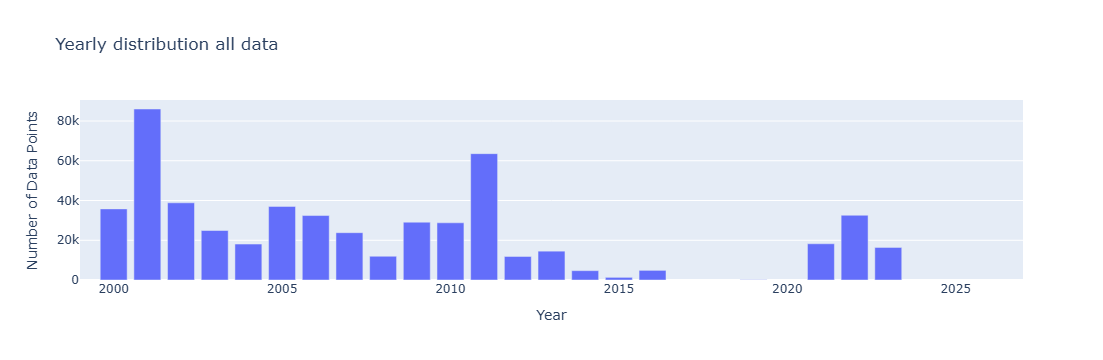

In [4]:
year_test=seabass.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

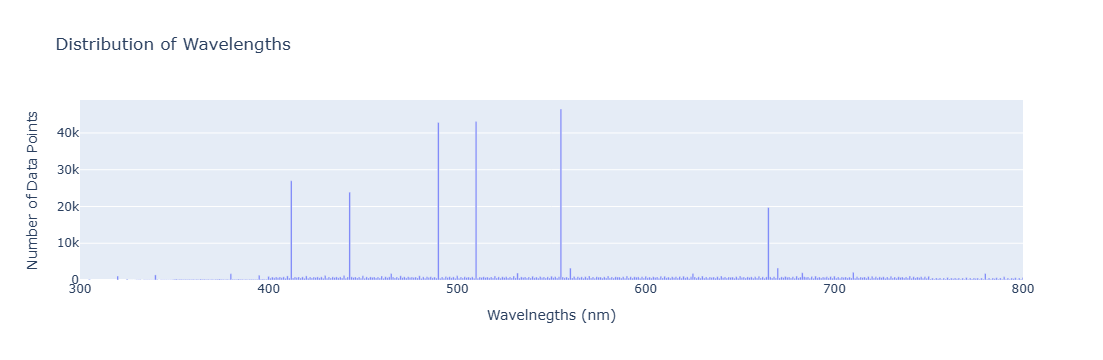

In [5]:
#how many wavelengths
grouped = year_test.groupby(['wavelength']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='wavelength', y='DataPoints', title='Distribution of Wavelengths',
             labels={'wavelength': 'Wavelnegths (nm)', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[300,800])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

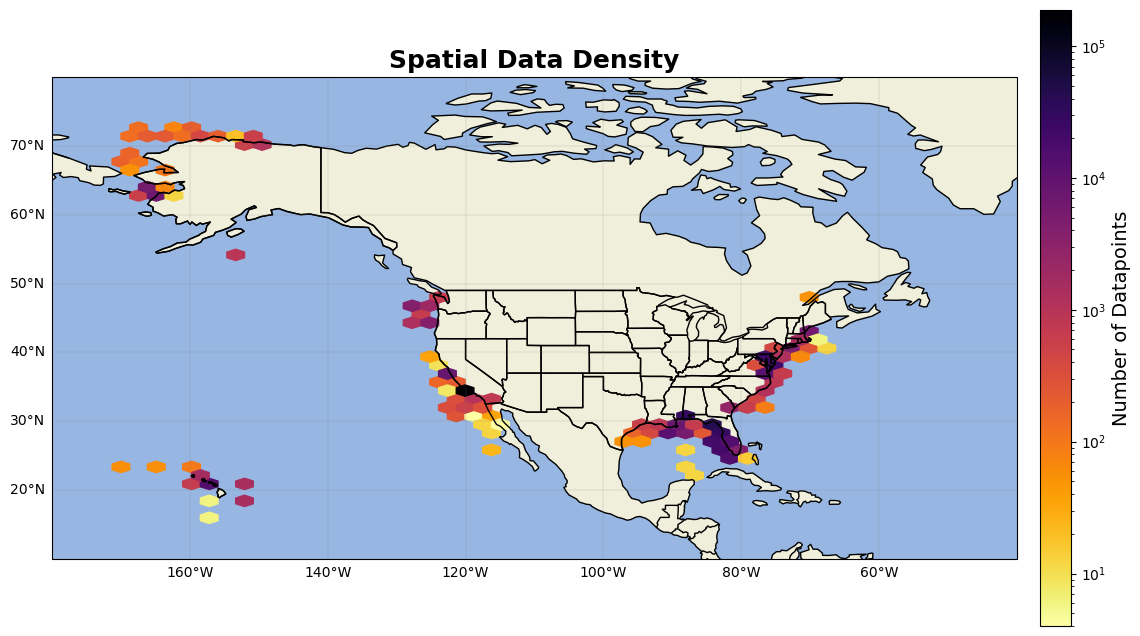

In [7]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=40, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()